In [259]:
#major libraries for data vis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#for stats
import numpy as np
from scipy.stats import norm
import math

# **Setting Up Dataframe for Analysis & Visualization**

In [260]:
#Import from csv to data frame
df = pd.read_csv('/Users/kajethjegatheesan/Downloads/rawDataAssignment1.csv')
#For ref, 55 participants per condition

df.head()

,SubjNo,Condition,NavTime,AccuracyScore,Age,Handedness,Sex
0,1,NoGame,139.442,98,28,R,F
1,2,NoGame,171.847,92,21,R,M
2,3,NoGame,69.529,86,35,R,F
3,4,NoGame,147.554,96,32,R,F
4,5,NoGame,133.969,79,21,R,F


### ***Following Cell contains generalized plot function for any condition and any DV***

To use the following function, provide the specific condition ('NoGame', 'Tetris', or 'BOTW') for the 'cdtn' parameter.

Provide the DV ('NavTime' or 'Accuracy') as 'dv'. 

The 'grph' parameter will default to a KDEplot, providing the value of 'hist' will change it to a histogram. 

The 'xbnds' parameter will default to an lower bound of 0 and upper bound of 500, these can be changed by providing a list with the 0-index as the lower bound and the 1-index as the upper bound.

In [261]:
def plot(cdtn, dv, grph = 'kde', xbnds = [0,500], show_outliers = False, bns = 10, sig_h=0.015, sig_x=0):
    tmp = df.loc[df['Condition']==cdtn]

    #for intial graph of data, either kdeplot or hist
    if grph == 'hist':
        sns.histplot(tmp, x = dv, bins=bns, stat='density')
        plt.plot()
    else:
        sns.kdeplot(tmp, x = dv, fill = True, alpha = 0.9)
    

    
    
    #dataframe to array conversion for stats
    arr = tmp[dv].to_numpy()

    #sample statistics
    sig = np.std(arr, ddof = 1)
    mu = np.average(arr)

    #Theorectical norm dist
    x = np.linspace(mu - sig*2.5, mu + sig*2.5, 100)

    y = norm.pdf(x,loc = mu, scale = sig)

    plt.plot(x,y, color = 'black', linestyle = 'dashed', alpha = 0.5)
    plt.xlim(xbnds[0],xbnds[1])

    #Centre of distribution
    plt.axvline(x=mu, color = 'blue', alpha = 0.6)
    plt.annotate(rf'$\sigma$ = {round(mu,4)}', (mu+1+sig_x, sig_h), fontsize = 6)


    #check for outliers with 2.5 std around mean
    lwrbnd = mu - 2.5*sig
    uprbnd = mu + 2.5*sig
    if show_outliers == True:
        for x in tmp['SubjNo']:
            if lwrbnd <= tmp[dv][x-1] <= uprbnd:
                pass
            else:
                print(f'{x} is an outlier with value {tmp[dv][x-1]}')



# **Data Analysis for No Game Condition**

## **NavTime Analysis**

In [262]:
#NoGame condition dataframe NavTime
ng = df.loc[df['Condition']== 'NoGame']

ng.head()

,SubjNo,Condition,NavTime,AccuracyScore,Age,Handedness,Sex
0,1,NoGame,139.442,98,28,R,F
1,2,NoGame,171.847,92,21,R,M
2,3,NoGame,69.529,86,35,R,F
3,4,NoGame,147.554,96,32,R,F
4,5,NoGame,133.969,79,21,R,F


(0.0, 250.0)

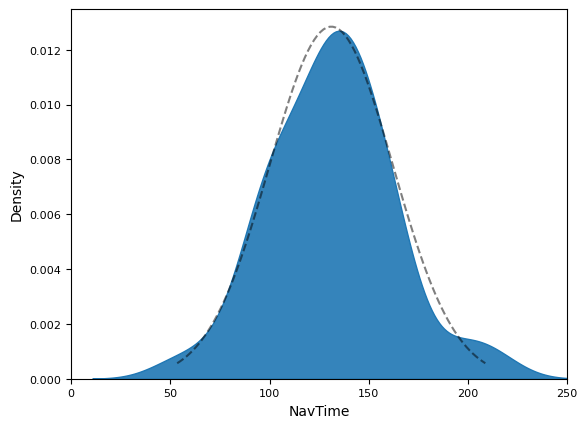

In [263]:
#NoGame condition kdeplot vs. norm NavTime
sns.kdeplot(ng, x = 'NavTime', fill=True, alpha = 0.9)

#stats prep
arr_1 = ng['NavTime'].to_numpy()

#sample statistics
sig = np.std(arr_1, ddof = 1)
mu = np.average(arr_1)
#print(sig, mu)

#Theorectical norm dist
x = np.linspace(mu - sig*2.5, mu + sig*2.5, 100)

y = norm.pdf(x,loc = mu, scale = sig)

plt.plot(x,y, color = 'black', linestyle = 'dashed', alpha = 0.5)
plt.xlim(0,250)


(0.0, 250.0)

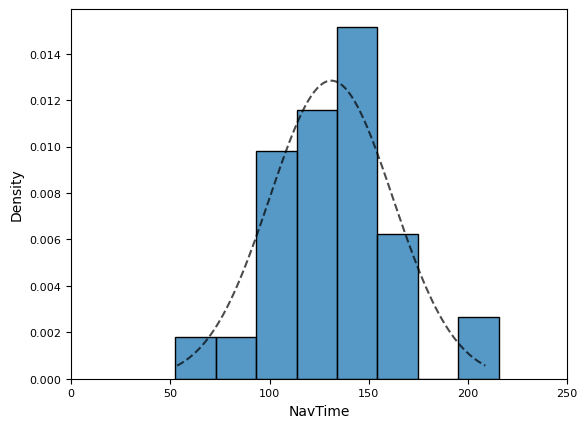

In [264]:
#NoGame condition hist vs. norm NavTime
sns.histplot(ng, x = 'NavTime', stat='density')

plt.plot(x,y, color = 'black', linestyle = 'dashed', alpha = 0.7)

plt.xlim(0, 250)

In [265]:
#check for outliers with 2.5 std around mean
lwrbnd = mu - 2.5*sig
uprbnd = mu + 2.5*sig
#print(lwrbnd, uprbnd)
#53.37747789155186 208.69623119935727

for x in ng['SubjNo']:
    if lwrbnd <= ng['NavTime'][x-1] <= uprbnd:
        pass
    else:
        print(f'{x} is an outlier with value {ng['NavTime'][x-1]}')

#We have outlier entries 9 & 35(aka index 8 & 34)

9 is an outlier with value 215.46
35 is an outlier with value 52.393


## **Accuracy Analysis**

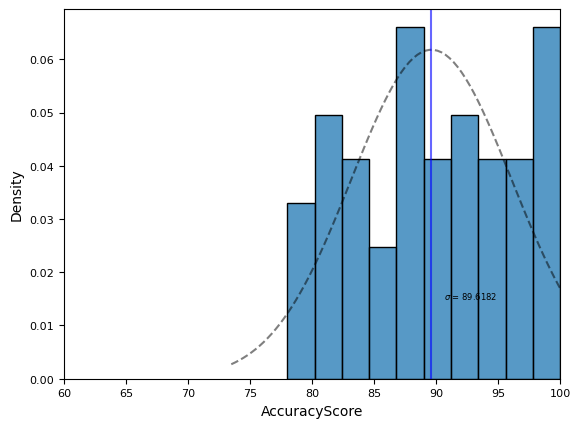

In [266]:
#Repeat for Accuracy scores
plot('NoGame', 'AccuracyScore', xbnds=[60,100], grph='hist', show_outliers=True)



# **Data analysis for Tetris Condition**

## **NavTime Analysis**

In [267]:
#Tetris condition dataframe NavTime
tg = df.loc[df['Condition']== 'Tetris']

tg.head()

,SubjNo,Condition,NavTime,AccuracyScore,Age,Handedness,Sex
110,111,Tetris,40.541,99,20,R,M
111,112,Tetris,73.010,96,34,R,F
112,113,Tetris,127.865,97,28,R,M
113,114,Tetris,67.196,93,27,R,F
114,115,Tetris,118.024,93,22,R,M


(0.0, 250.0)

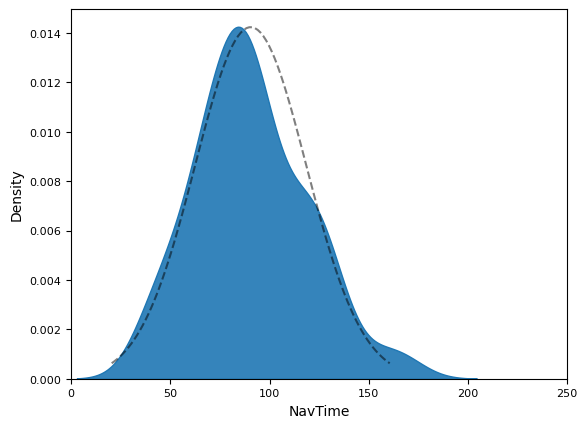

In [268]:
#NoGame condition kdeplot vs. norm NavTime
sns.kdeplot(tg, x = 'NavTime', fill=True, alpha = 0.9)

#stats prep
arr_2 = tg['NavTime'].to_numpy()

#sample statistics
sig_2 = np.std(arr_2, ddof = 1)
mu_2 = np.average(arr_2)
#print(sig, mu)

#Theorectical norm dist
x_2 = np.linspace(mu_2 - sig_2*2.5, mu_2 + sig_2*2.5, 100)

y_2 = norm.pdf(x_2,loc = mu_2, scale = sig_2)

plt.plot(x_2,y_2, color = 'black', linestyle = 'dashed', alpha = 0.5)
plt.xlim(0, 250)

(0.0, 250.0)

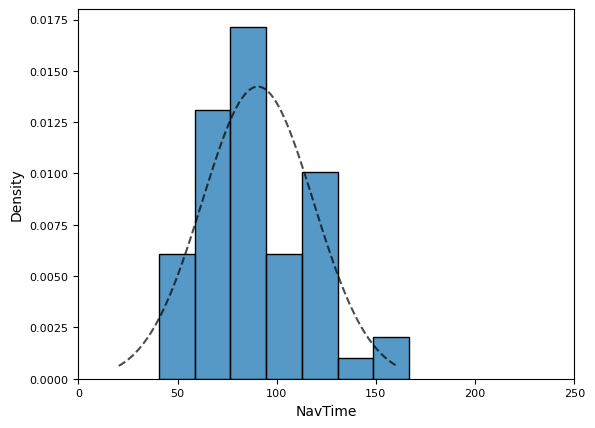

In [269]:
#NoGame condition hist vs. norm NavTime
sns.histplot(tg, x = 'NavTime', stat='density')

plt.plot(x_2,y_2, color = 'black', linestyle = 'dashed', alpha = 0.7)
plt.xlim(0, 250)

In [270]:
#check for outliers with 2.5 std around mean
lwrbnd = mu_2 - 2.5*sig_2
uprbnd = mu_2 + 2.5*sig_2
#print(lwrbnd, uprbnd)
#20.36595469480227 160.49880894156138


for x in tg['SubjNo']:
    if lwrbnd <= tg['NavTime'][x-1] <= uprbnd:
        pass
    else:
        print(f'{x} is an outlier with value {tg['NavTime'][x-1]}')

#We have outlier entries 121(aka index 120)

121 is an outlier with value 166.7


## **Accuracy Analysis**

140 is an outlier with value 32


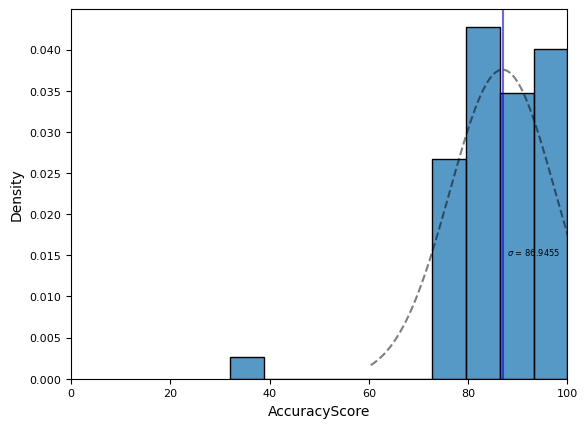

In [271]:
#repeat for accuracy
plot('Tetris', 'AccuracyScore', xbnds=[0,100], grph = 'hist', show_outliers=True)

# **Data Analysis for BOTW Condition**

## **NavTime Analysis**

In [272]:
bg = df.loc[df['Condition']== 'BOTW']

bg.head()

,SubjNo,Condition,NavTime,AccuracyScore,Age,Handedness,Sex
55,56,BOTW,91.316,93,29,R,F
56,57,BOTW,33.758,95,35,R,F
57,58,BOTW,62.284,100,31,R,M
58,59,BOTW,47.360,78,29,R,M
59,60,BOTW,80.934,85,30,R,F


94 is an outlier with value 117.637


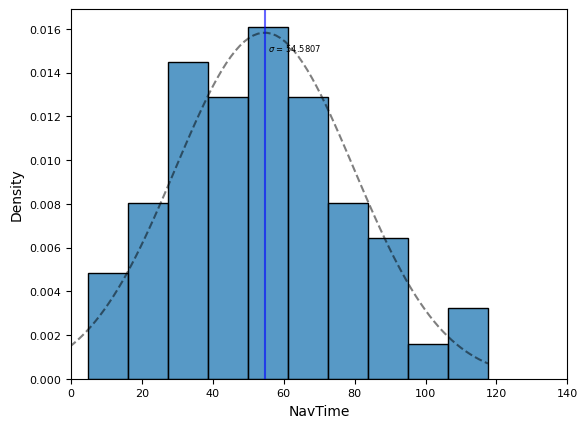

In [273]:
plot('BOTW', 'NavTime', grph = 'hist', xbnds=[0,140], show_outliers=True)

## **Accuracy Analysis**

77 is an outlier with value 44
85 is an outlier with value 48


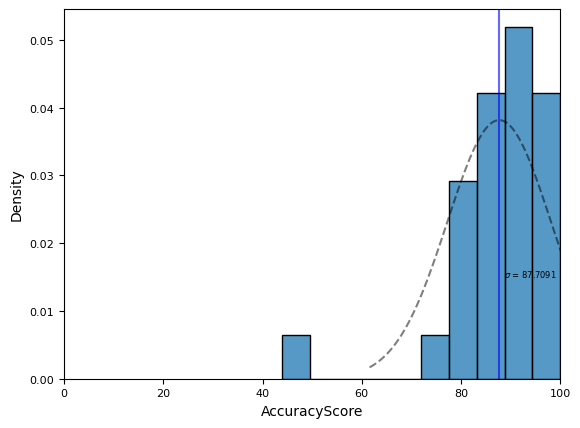

In [274]:
plot('BOTW', 'AccuracyScore', grph = 'hist', xbnds=[0,100], show_outliers=True)

# **Overall comparison of conditions over NavTime & AccuracyScore**

Text(5, 0.0585, 'f)')

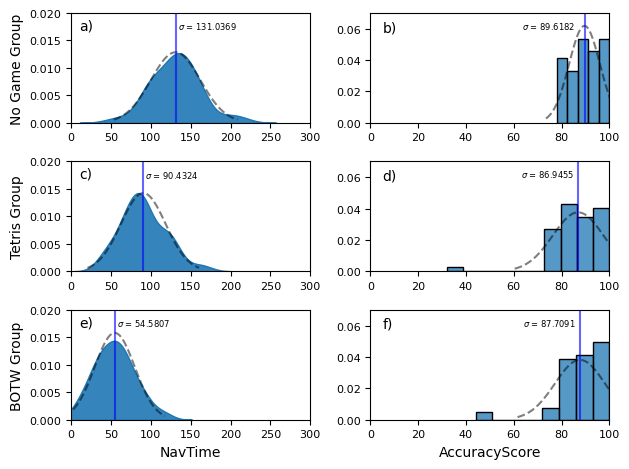

In [275]:
#Create single figure for comparison
fig= plt.subplots(3,2, tight_layout = True)

#axis tick mark font size
tck = 8
plt.rcParams['xtick.labelsize'] = tck
plt.rcParams['ytick.labelsize'] = tck

#upper bound for nav time
up = 300


#Subplot code

#Row 1, Column 1: No Game (Nav Time)
plt.subplot(3,2,1)
plot('NoGame', 'NavTime', xbnds = [0,up], sig_h= 0.017, sig_x = 2)
plt.ylim((0,0.02))
plt.xlabel('')
plt.ylabel('No Game Group')
plt.annotate('a)', (10, 0.017))

#Row 1, Column 2: No Game (Accuracy)
plt.subplot(3,2,2)
plot('NoGame', 'AccuracyScore', xbnds=[0,100], grph='hist', bns=5, sig_h = 0.06, sig_x = -27)
plt.ylabel('')
plt.xlabel('')
plt.ylim((0,0.07))
plt.annotate('b)', (5, 0.0585))

#Row 2, Column 1: Tetris (Nav Time)
plt.subplot(3,2,3)
plot('Tetris', 'NavTime', xbnds=[0,up], sig_h= 0.017, sig_x = 1)
plt.ylim((0,0.02))
plt.xlabel('')
plt.ylabel('Tetris Group')
plt.annotate('c)', (10, 0.017))

#Row 2, Column 2: Tetris (Accuracy)
plt.subplot(3,2,4)
plot('Tetris', 'AccuracyScore', xbnds=[0,100], grph = 'hist', sig_h = 0.06, sig_x = -25)
plt.ylabel('')
plt.xlabel('')
plt.ylim((0,0.07))
plt.annotate('d)', (5, 0.0585))

#Row 3, Column 1: BOTW (Nav Time)
plt.subplot(3,2,5)
plot('BOTW', 'NavTime', xbnds=[0,up], sig_h = 0.017, sig_x = 2)
plt.ylim((0,0.02))
plt.ylabel('BOTW Group')
plt.annotate('e)', (10, 0.017))

#Row 3, Column 2: BOTW (Accuracy)
plt.subplot(3,2,6)
plot('BOTW', 'AccuracyScore', xbnds=[0,100], grph = 'hist', bns=8, sig_h = 0.06, sig_x = -25)
plt.ylabel('')
plt.ylim((0,0.07))
plt.annotate('f)', (5, 0.0585))



Notes for Discussion:
- The nav time variance between groups is different, the control is more varied in comparison to the Tetris and BOTW groups. This is indicative of the fact that untrained people will have a varied navigational time in a novel environment. Meanwhile, trained individuals will have more standardized times given they are more experienced at navigating novel spatial environments.

- 


### **Figure for Comparison of Groups**

31.06375066156108 28.026570849351824 25.21444434215241


<BarContainer object of 3 artists>

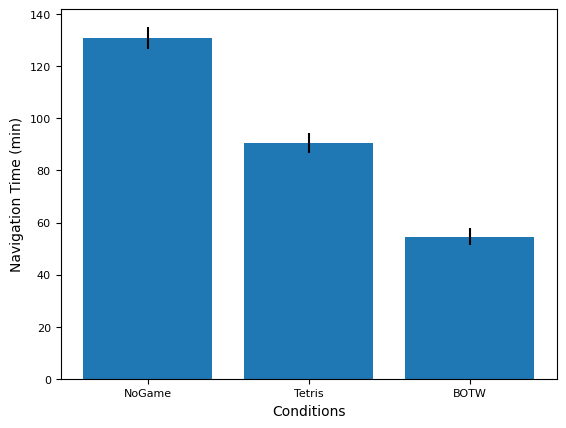

In [279]:
#Stats for BOTW
#stats prep
arr_3 = bg['NavTime'].to_numpy()

#sample statistics
sig_3 = np.std(arr_3, ddof = 1)
mu_3 = np.average(arr_3)

print(sig, sig_2, sig_3)

plt.ylabel('Navigation Time (min)')
plt.xlabel('Conditions')

plt.bar(x = ['NoGame', 'Tetris', 'BOTW'], height = [mu, mu_2, mu_3], yerr = [sig/math.sqrt(55), sig_2/math.sqrt(55), sig_3/math.sqrt(55)])